In [22]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA   = "/Users/aidan.kelly/nesta/discovery/discovery_mission_radar/discovery_mission_radar/outputs/ASF/heat_pumps/crunchbase/csv/Heat pumps_funding_rounds.csv"  # adapt if needed

# --- region & stage maps you already have ------------------------------
REGION_TO_COUNTRIES = {
    "North America + Australia": ["USA", "CAN", "AUS", "NZL"],
    "South + Central America": [
        "VEN",
        "ARG",
        "BRA",
        "CHL",
        "COL",
        "PER",
        "URY",
        "PRY",
        "ECU",
        "BOL",
        "GUY",
        "SUR",
        "MEX",
        "CRI",
        "SLV",
        "GTM",
        "HND",
        "PAN",
        "NIC",
    ],
    "Europe": [
        "IRL",
        "LUX",
        "CHE",
        "ESP",
        "DEU",
        "FRA",
        "FIN",
        "SWE",
        "NLD",
        "BEL",
        "DNK",
        "CZE",
        "POL",
        "EST",
        "AUT",
        "ITA",
        "ROU",
        "CYP",
        "NOR",
        "PRT",
        "BGR",
        "BLR",
        "SVN",
        "ARM",
        "HUN",
        "ISL",
        "LVA",
        "LTU",
        "HRV",
        "MKD",
        "BIH",
        "SRB",
        "SVK",
        "GEO",
        "MDA",
        "ALB",
        "SMR",
        "AND",
        "GIB",
        "FRO",
        "LIE",
        "IMN",
        "GGY",
        "JEY",
        "ALA",
    ],
    "UK": ["GBR"],
    "Asia": [
        "IND",
        "HKG",
        "ISR",
        "RUS",
        "KOR",
        "SGP",
        "JPN",
        "ARE",
        "CHN",
        "PHL",
        "IDN",
        "THA",
        "TUR",
        "MYS",
        "TWN",
        "PAK",
        "LBN",
        "ARM",
        "BGD",
        "KWT",
        "VNM",
        "MDV",
        "JOR",
        "LKA",
        "IRN",
        "SYR",
        "KAZ",
        "UZB",
        "IRQ",
        "OMN",
        "PSE",
        "TJK",
        "BTN",
        "TLS",
        "MAC",
        "MMR",
        "MNG",
        "KHM",
        "LAO",
        "BRN",
    ],
    "Africa": [
        "ZAF",
        "MUS",
        "EGY",
        "GHA",
        "KEN",
        "NGA",
        "MAR",
        "CIV",
        "ETH",
        "TUN",
        "MOZ",
        "UGA",
        "SEN",
        "ZWE",
        "RWA",
        "SDN",
    ],
    "Middle East": ["SAU", "ARE", "KWT", "QAT", "OMN", "IRQ", "IRN", "SYR", "JOR", "LBN", "ISR", "YEM"],
    "Rest of the World": [None, "BMU", "TTO", "GLP", "CYM", "IMN"],
}  
      
INVESTMENT_STAGES    =  {
    "early_stage": [
        "pre_seed",
        "seed",
        "angel",
        "series_a",
        "series_b",
        "convertible_note",
        "equity_crowdfunding",
        "product_crowdfunding",
        "grant",
        "non_equity_assistance",
        "initial_coin_offering",
    ],
    "growth_stage": ["series_c", "series_d", "series_e", "series_f", "series_g", "series_h", "series_i", "series_j"],
    "late_stage": ["private_equity", "post_ipo_equity", "post_ipo_debt", "post_ipo_secondary", "secondary_market"],
    "other": ["corporate_round", "debt_financing"],
    "uncategorized": ["series_unknown", "undisclosed"],
}

# Flatten the dicts → faster look-ups
COUNTRY_TO_REGION = {
    c: r for r, countries in REGION_TO_COUNTRIES.items() for c in countries
}
INVEST_TYPE_TO_STAGE = {
    inv_type: stage for stage, types in INVESTMENT_STAGES.items() for inv_type in types
}

In [23]:
print(COUNTRY_TO_REGION)
print(INVEST_TYPE_TO_STAGE)

{'USA': 'North America + Australia', 'CAN': 'North America + Australia', 'AUS': 'North America + Australia', 'NZL': 'North America + Australia', 'VEN': 'South + Central America', 'ARG': 'South + Central America', 'BRA': 'South + Central America', 'CHL': 'South + Central America', 'COL': 'South + Central America', 'PER': 'South + Central America', 'URY': 'South + Central America', 'PRY': 'South + Central America', 'ECU': 'South + Central America', 'BOL': 'South + Central America', 'GUY': 'South + Central America', 'SUR': 'South + Central America', 'MEX': 'South + Central America', 'CRI': 'South + Central America', 'SLV': 'South + Central America', 'GTM': 'South + Central America', 'HND': 'South + Central America', 'PAN': 'South + Central America', 'NIC': 'South + Central America', 'IRL': 'Europe', 'LUX': 'Europe', 'CHE': 'Europe', 'ESP': 'Europe', 'DEU': 'Europe', 'FRA': 'Europe', 'FIN': 'Europe', 'SWE': 'Europe', 'NLD': 'Europe', 'BEL': 'Europe', 'DNK': 'Europe', 'CZE': 'Europe', 'POL'

In [24]:
# 🔹 Crunchbase export already has country_code + investment_type columns
rounds = (pd.read_csv(DATA, low_memory=False)
            .assign(
                region=lambda d: d["country_code"].map(COUNTRY_TO_REGION),
                stage =lambda d: d["investment_type"].map(INVEST_TYPE_TO_STAGE),
                year  =lambda d: pd.to_datetime(d["announced_on"]).dt.year,
            ))

# Keep only the years that matter for the chart you showed
rounds = rounds.query("2020 <= year <= 2024")

In [25]:

country_stage = (rounds
    .query("stage in ['early_stage', 'growth_stage']")
    .groupby(["country_code", "stage"], as_index=False)
    .agg(gbp=("raised_amount_gbp", "sum"))
    # nicer units for a chart: £ millions, 1 decimal
    .assign(gbp_m=lambda d: d["gbp"] / 1_000_000)
)


## Region-level plots
Run the next two cells to generate stacked bar charts for investment amounts and round counts by region. Select each cell and press Shift+Enter.

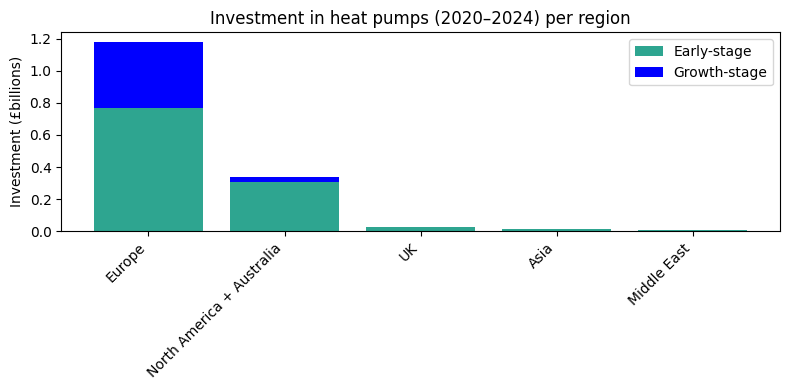

In [27]:
# 🔹 Investment per region bar chart
region_pivot = region_stage.pivot(index='region', columns='stage', values='gbp_m').fillna(0).reset_index()
# Sort by early_stage descending
region_sorted = region_pivot.sort_values('early_stage', ascending=False)
regions = region_sorted['region']
early_amt = region_sorted['early_stage']
growth_amt = region_sorted['growth_stage']
plt.figure(figsize=(8, 4))
plt.bar(regions, early_amt, label='Early-stage', color="#2ea590")
plt.bar(regions, growth_amt, bottom=early_amt, label='Growth-stage', color="blue")
plt.ylabel("Investment (£billions)")
plt.title("Investment in heat pumps (2020–2024) per region")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

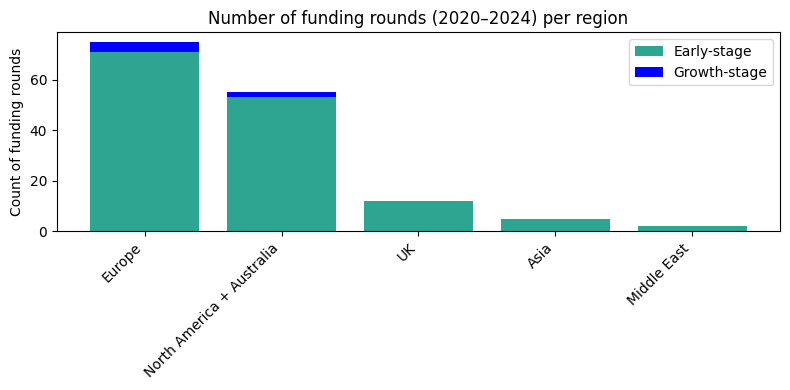

In [28]:
# 🔹 Plot counts of funding rounds per region
region_stage_counts = (
    rounds
    .query("stage in ['early_stage', 'growth_stage']")
    .groupby(['region', 'stage'])
    .size()
    .reset_index(name='count')
    .pivot(index='region', columns='stage', values='count')
    .fillna(0)
    .reset_index()
)

# Sort by total descending
region_counts_sorted = region_stage_counts.assign(total=lambda d: d['early_stage'] + d['growth_stage']).sort_values('total', ascending=False)
regions = region_counts_sorted['region']
early_counts = region_counts_sorted['early_stage']
growth_counts = region_counts_sorted['growth_stage']

plt.figure(figsize=(8, 4))
plt.bar(regions, early_counts, label='Early-stage', color="#2ea590")
plt.bar(regions, growth_counts, bottom=early_counts, label='Growth-stage', color="blue")
plt.ylabel("Count of funding rounds")
plt.title("Number of funding rounds (2020–2024) per region")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
uk_de_fr = (country_stage
              .query("country_code in ['GBR', 'DEU', 'FRA']")
              .pivot(index="country_code",
                     columns="stage",
                     values="gbp_m")
              .fillna(0)
              .reset_index()
              .rename(columns={"country_code": "country"}))

print(uk_de_fr)

stage country  early_stage  growth_stage
0         DEU     0.428228      0.412917
1         FRA     0.005539      0.000000
2         GBR     0.027305      0.000000


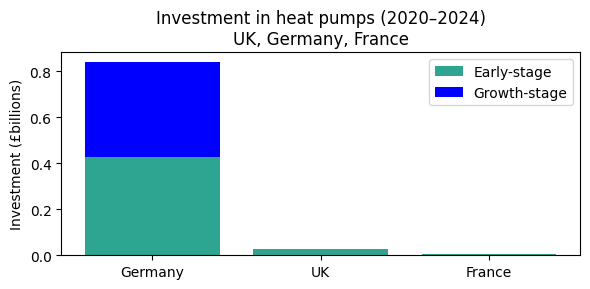

In [21]:
import matplotlib.pyplot as plt

# Sort by early_stage descending
uk_de_fr_sorted = uk_de_fr.sort_values("early_stage", ascending=False)

# Extract data
countries = uk_de_fr_sorted["country"]
early_stage = uk_de_fr_sorted["early_stage"]
growth_stage = uk_de_fr_sorted["growth_stage"]

# Plot
plt.figure(figsize=(6, 3))

# Bottom bar: early stage
plt.bar(countries, early_stage, label='Early-stage', color="#2ea590")

# Top bar: growth stage, stacked on early stage
plt.bar(countries, growth_stage, bottom=early_stage, label='Growth-stage', color="blue")

# Add labels and formatting
plt.ylabel("Investment (£billions)")
plt.title("Investment in heat pumps (2020–2024)\nUK, Germany, France")
plt.xticks(countries, countries.map({"DEU": "Germany", "FRA": "France", "GBR": "UK"}))
plt.legend()
plt.tight_layout()
plt.show()

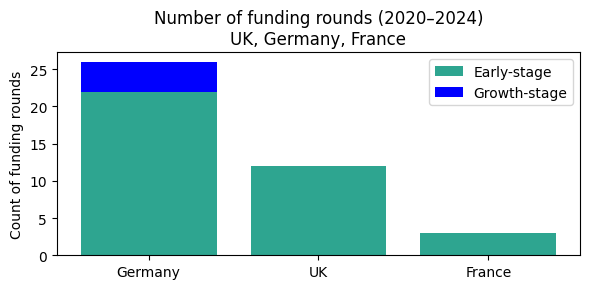

In [20]:
# Sort by total bar height (early_stage + growth_stage)
uk_de_fr_counts_sorted = uk_de_fr_counts.assign(
    total=lambda d: d["early_stage"] + d["growth_stage"]
).sort_values("total", ascending=False)

countries = uk_de_fr_counts_sorted['country']
early_counts = uk_de_fr_counts_sorted['early_stage']
growth_counts = uk_de_fr_counts_sorted['growth_stage']

plt.figure(figsize=(6, 3))
plt.bar(countries, early_counts, label='Early-stage', color="#2ea590")
plt.bar(countries, growth_counts, bottom=early_counts, label='Growth-stage', color="blue")
plt.ylabel("Count of funding rounds")
plt.title("Number of funding rounds (2020–2024)\nUK, Germany, France")
plt.xticks(countries, countries.map({"DEU": "Germany", "FRA": "France", "GBR": "UK"}))
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
# 🔹 Germany investment as % of Europe total
germany_amt = country_stage.query("country_code=='DEU'")["gbp_m"].sum()
europe_amt = region_stage.query("region=='Europe'")["gbp_m"].sum()
pct = germany_amt / europe_amt * 100 if europe_amt else 0
print(f"Germany accounts for {pct:.1f}% of Europe's heat pump investment (2020–2024)")

Germany accounts for 71.3% of Europe's heat pump investment (2020–2024)


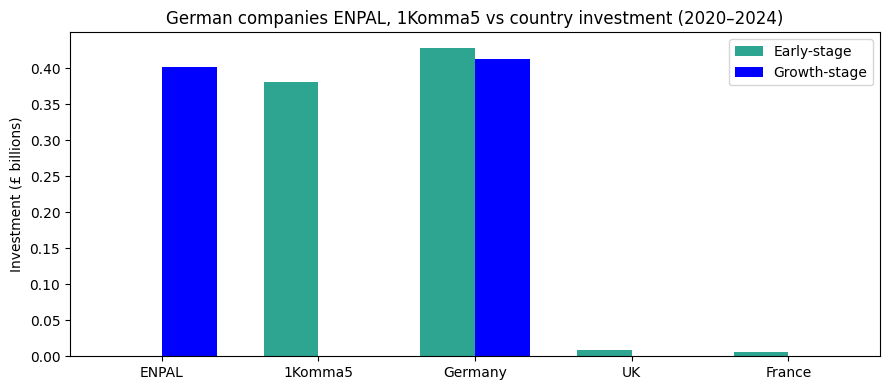

In [44]:
# Add 1Komma5 to the comparison
# Case-insensitive match for '1komma5' in funding_round_name
komma5 = rounds_fg[rounds_fg['funding_round_name'].str.contains('1komma5', case=False, na=False)]
komma5_early = komma5[komma5['stage'] == 'early_stage']['gbp_m'].sum()
komma5_growth = komma5[komma5['stage'] == 'growth_stage']['gbp_m'].sum()

# Update values and labels
early_vals = [enpal_early, komma5_early] + [amt(c, 'early_stage') for c in codes]
growth_vals = [enpal_growth, komma5_growth] + [amt(c, 'growth_stage') for c in codes]
labels = ['ENPAL', '1Komma5', 'Germany', 'UK', 'France']

# Plot grouped bar chart
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(9, 4))
plt.bar(x - width/2, early_vals, width, label='Early-stage', color="#2ea590")
plt.bar(x + width/2, growth_vals, width, label='Growth-stage', color="blue")
plt.xticks(x, labels)
plt.ylabel("Investment (£ billions)")
plt.title("German companies ENPAL, 1Komma5 vs country investment (2020–2024)")
plt.legend()
plt.tight_layout()
plt.show()
